# VocEd Lab 02 — Bayesian Optimisation of Thresholds

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/02_bayesian_optimisation.ipynb)

In Lab 01 we chose threshold values by eye — we looked at the histogram and picked numbers
that seemed reasonable.  That works, but it raises an obvious question: **are those the
*best* thresholds?**  And what does "best" even mean?

In this lab we replace hand-picking with **Bayesian optimisation**: an algorithm that
intelligently searches the space of possible threshold pairs and finds the combination that
maximises the mean Dice score.

We also introduce the **train/test split**, which becomes essential the moment we start
fitting anything to the data.

By the end of this lab you will be able to:
- Explain why a train/test split is necessary when optimising hyperparameters.
- Define an *objective function* that maps threshold values to a Dice score.
- Run `skopt.gp_minimize` to search for the best threshold pair.
- Interpret convergence curves and 2-D Dice surfaces.
- Compare optimised vs hand-picked thresholds on held-out test images.

## 0. Setup — Install Dependencies & Clone the Repository

In [1]:
!pip install scikit-optimize --quiet

# Clone the repo
!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.8 MB/s eta 0:00:00
Cloning into 'VocEd'...
remote: Enumerating objects: 663, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 663 (delta 55), reused 67 (delta 30), pack-reused 566 (from 1)
Receiving objects: 100% (663/663), 34.36 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Updating files: 100% (417/417), done.
/content/VocEd


## 1. Load Data

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt

N = len(glob.glob('imagedata/X/*.npy'))
X = np.stack([np.load(f'imagedata/X/{i}.npy') for i in range(N)])
y = np.stack([np.load(f'imagedata/y/{i}.npy') for i in range(N)])

# Drop images with no nucleus pixels
has_nucleus = (y == 2).sum(axis=(1, 2)) > 0
X, y = X[has_nucleus], y[has_nucleus]
N = len(X)
print(f'{N} images retained  ({(~has_nucleus).sum()} with no nucleus removed)')

191 images retained  (9 with no nucleus removed)


## 2. Train / Test Split

We hold out 20 % of images as a test set that the optimiser never sees.

The split is **stratified by N/C ratio** (nucleus pixels ÷ cytoplasm pixels) — we bin
images by their nucleus-to-cytoplasm ratio and ensure each quartile is proportionally
represented in both sets.  This is more meaningful than raw nucleus size, which can be
large simply because the image is larger; N/C ratio is size-invariant and directly
reflects the cell-morphology feature we are trying to predict.

In [3]:
from sklearn.model_selection import train_test_split

# Stratify by N/C ratio (nucleus pixels / cytoplasm pixels).
# This is size-invariant: a large image with large nucleus and large cytoplasm
# can have the same N/C ratio as a small image, so the split is fair.
nuc_px   = (y == 2).sum(axis=(1, 2))
cyt_px   = (y == 1).sum(axis=(1, 2))
nc_ratio = nuc_px / np.maximum(cyt_px, 1)   # np.maximum avoids div-by-zero
quartile = np.digitize(nc_ratio, np.percentile(nc_ratio, [25, 50, 75]))

#Split the indeces of images into train and test using quartile stratification. 'stratify'
# ensures that an equal proportion from each quartile is used in the split
train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.2, stratify=quartile, random_state=42
)

print(f'Training images : {len(train_idx)}')
print(f'Test images     : {len(test_idx)}')

Training images : 152
Test images     : 39


## 3. Helper Functions

We need two functions we will call repeatedly: one to convert RGB to grayscale, and one
to compute the Dice score.  These are identical to Lab 01.

In [4]:
def to_gray(img):
    """Convert a (3, H, W) float32 image to (H, W) grayscale using the luminance formula."""
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]


def dice_score(pred, target, cls):
    """Dice score for a single class label (higher is better; 1.0 = perfect)."""
    pred_mask   = (pred   == cls)
    target_mask = (target == cls)
    intersection = (pred_mask & target_mask).sum()
    denominator  = pred_mask.sum() + target_mask.sum()
    if denominator == 0:
        return 1.0   # both empty → perfect match by convention
    return 2 * intersection / denominator


def segment(img, t_nucleus, t_background):
    """Apply two-threshold segmentation to a single (3, H, W) image."""
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)          # start: everything is background (0)
    pred[gray < t_nucleus]                                = 2   # dark pixels → nucleus
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1   # mid pixels  → cytoplasm
    return pred


def mean_dice(indices, t_nucleus, t_background):
    """Mean Dice (cyto + nucleus averaged) over a set of image indices."""
    scores = []
    for i in indices:
        pred = segment(X[i], t_nucleus, t_background)
        d_cyto = dice_score(pred, y[i], cls=1)
        d_nuc  = dice_score(pred, y[i], cls=2)
        scores.append((d_cyto + d_nuc) / 2)
    return np.mean(scores)


# Quick sanity check with Lab 01's hand-picked values
lab01_nuc = 0.45
lab01_bg  = 0.85
train_dice_lab01 = mean_dice(train_idx, lab01_nuc, lab01_bg)
test_dice_lab01  = mean_dice(test_idx,  lab01_nuc, lab01_bg)
print(f'Lab 01 thresholds  →  train Dice: {train_dice_lab01:.4f}   test Dice: {test_dice_lab01:.4f}')

Lab 01 thresholds  →  train Dice: 0.7125   test Dice: 0.7441


## 4. The Objective Function

Bayesian optimisation needs a **single number** to maximise (or minimise) for each pair
of threshold values it tries.  We call this the *objective function*.

Our objective: **negative mean Dice over the training set**.  We use the negative because
`gp_minimize` looks for the *minimum* by convention, so minimising the negative Dice is
the same as maximising Dice.

In [5]:
# ── Objective function expected by skopt ──────────────────────────────────────
# skopt passes a list of parameter values; we unpack t_nucleus and t_background from it.
def objective(params):
    t_nucleus, t_background = params
    # Return NEGATIVE Dice because gp_minimize minimises; we want to maximise Dice.
    return -mean_dice(train_idx, t_nucleus, t_background)


# Test the objective at the Lab 01 values — should match what we computed above
print('Objective at Lab 01 thresholds:', objective([lab01_nuc, lab01_bg]))

Objective at Lab 01 thresholds: -0.712460088248467


## 5. Bayesian Optimisation with `gp_minimize`

**How it works (brief intuition):**  Instead of trying threshold pairs at random, Bayesian
optimisation builds a *surrogate model* — a fast approximation of the objective function —
and uses it to decide which pair to try next.  After each evaluation it updates the
surrogate with the new result.  Over time the surrogate becomes accurate, and the search
focuses on the region where Dice is highest.

The `gp_minimize` function uses a **Gaussian Process** as the surrogate model.  You don't
need to understand the maths; the key parameters are:

| Parameter | What it controls |
|---|---|
| `dimensions` | The search space — min/max for each parameter |
| `n_calls` | Total number of threshold pairs to evaluate |
| `n_initial_points` | How many random pairs to try before fitting the surrogate |
| `random_state` | Seed for reproducibility |

In [6]:
from skopt import gp_minimize
from skopt.space import Real   # Real defines a continuous search range

# ── Define the search space ───────────────────────────────────────────────────
# t_nucleus must be in [0.1, 0.7]; t_background must be in [0.5, 0.99]
# (We constrain t_nucleus < t_background loosely via these ranges.)
search_space = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
]

# ── Run Bayesian optimisation ─────────────────────────────────────────────────
# n_calls=50 means we will evaluate 50 threshold pairs in total.
# The first n_initial_points=10 are random; the rest are guided by the surrogate.
print('Running Bayesian optimisation (50 evaluations)...')
result = gp_minimize(
    func          = objective,      # the function to minimise
    dimensions    = search_space,   # parameter ranges
    n_calls       = 50,             # total evaluations
    n_initial_points = 10,          # random warm-up evaluations
    random_state  = 42,             # reproducibility
    verbose       = False,
)
print('Done.')

# ── Extract the best result ───────────────────────────────────────────────────
best_nuc, best_bg = result.x   # result.x holds the best parameter values found
best_train_dice   = -result.fun  # result.fun is the minimum objective value (negative Dice)

print(f'\nBest thresholds found:')
print(f'  t_nucleus    = {best_nuc:.4f}')
print(f'  t_background = {best_bg:.4f}')
print(f'  Train Dice   = {best_train_dice:.4f}  (Lab 01: {train_dice_lab01:.4f})')

Running Bayesian optimisation (50 evaluations)...
Done.

Best thresholds found:
  t_nucleus    = 0.3935
  t_background = 0.9900
  Train Dice   = 0.7772  (Lab 01: 0.7125)


## 6. Convergence Curve

The convergence curve shows the **best Dice found so far** after each evaluation.  Early
evaluations are random, so scores jump around.  Once the surrogate model improves, the
curve flattens — meaning the algorithm has found the best it can with the given budget.

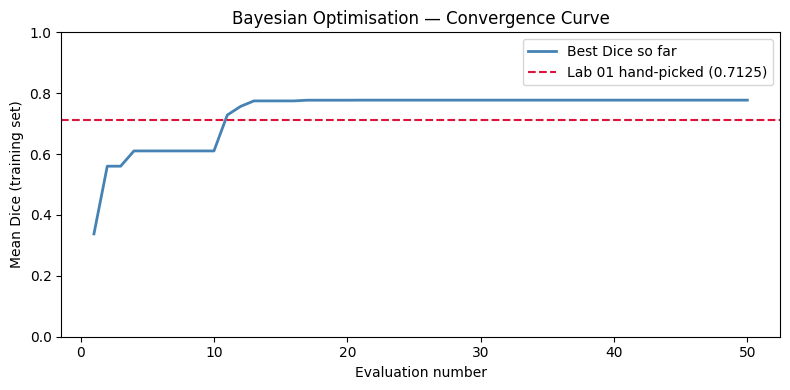

In [7]:
# result.func_vals contains the objective value (negative Dice) at each of the 50 evaluations
# We take the running minimum to get the "best so far" at each step
objective_values = np.array(result.func_vals)          # shape: (n_calls,)
best_so_far      = np.minimum.accumulate(objective_values)  # running minimum

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(best_so_far) + 1), -best_so_far,
        color='steelblue', linewidth=2, label='Best Dice so far')
ax.axhline(train_dice_lab01, color='crimson', linestyle='--',
           label=f'Lab 01 hand-picked ({train_dice_lab01:.4f})')
ax.set_xlabel('Evaluation number')
ax.set_ylabel('Mean Dice (training set)')
ax.set_title('Bayesian Optimisation — Convergence Curve')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. 2-D Dice Surface

To see what the optimiser was exploring, we can compute the mean Dice on a grid of
threshold pairs and plot it as a heatmap.  The best pair found by the optimiser should
lie near the brightest region.

Grid computation done.


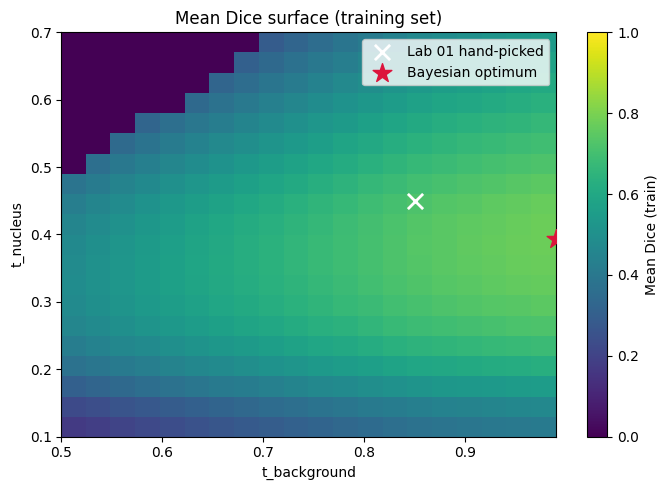

In [8]:
# ── Compute Dice on a 20×20 grid (uses training set only) ─────────────────────
grid_size = 20
nuc_vals  = np.linspace(0.10, 0.70, grid_size)
bg_vals   = np.linspace(0.50, 0.99, grid_size)

dice_grid = np.zeros((grid_size, grid_size))
for i, tn in enumerate(nuc_vals):
    for j, tb in enumerate(bg_vals):
        if tn >= tb:
            dice_grid[i, j] = 0.0   # invalid: nucleus threshold must be below background threshold
        else:
            dice_grid[i, j] = mean_dice(train_idx, tn, tb)

print('Grid computation done.')

# ── Plot the surface ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(dice_grid, origin='lower', aspect='auto',
               extent=[bg_vals[0], bg_vals[-1], nuc_vals[0], nuc_vals[-1]],
               cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Mean Dice (train)')

# Mark the hand-picked Lab 01 thresholds
ax.scatter(lab01_bg,  lab01_nuc,  marker='x', s=120, color='white',
           linewidths=2, label='Lab 01 hand-picked', zorder=5)

# Mark the optimised thresholds
ax.scatter(best_bg, best_nuc, marker='*', s=200, color='crimson',
           label='Bayesian optimum', zorder=5)

ax.set_xlabel('t_background')
ax.set_ylabel('t_nucleus')
ax.set_title('Mean Dice surface (training set)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Test-Set Evaluation

The moment of truth: how well do the optimised thresholds perform on the **40 images the
optimiser never saw**?

In [9]:
# ── Evaluate both threshold sets on the held-out test images ──────────────────
test_dice_lab01 = mean_dice(test_idx, lab01_nuc, lab01_bg)
test_dice_opt   = mean_dice(test_idx, best_nuc,  best_bg)

print('Test-set Dice comparison:')
print(f'  Lab 01 hand-picked  (t_nuc={lab01_nuc:.2f}, t_bg={lab01_bg:.2f}):  {test_dice_lab01:.4f}')
print(f'  Bayesian optimised  (t_nuc={best_nuc:.4f}, t_bg={best_bg:.4f}):  {test_dice_opt:.4f}')
print(f'  Improvement: {test_dice_opt - test_dice_lab01:+.4f}')

Test-set Dice comparison:
  Lab 01 hand-picked  (t_nuc=0.45, t_bg=0.85):  0.7441
  Bayesian optimised  (t_nuc=0.3935, t_bg=0.9900):  0.8199
  Improvement: +0.0758


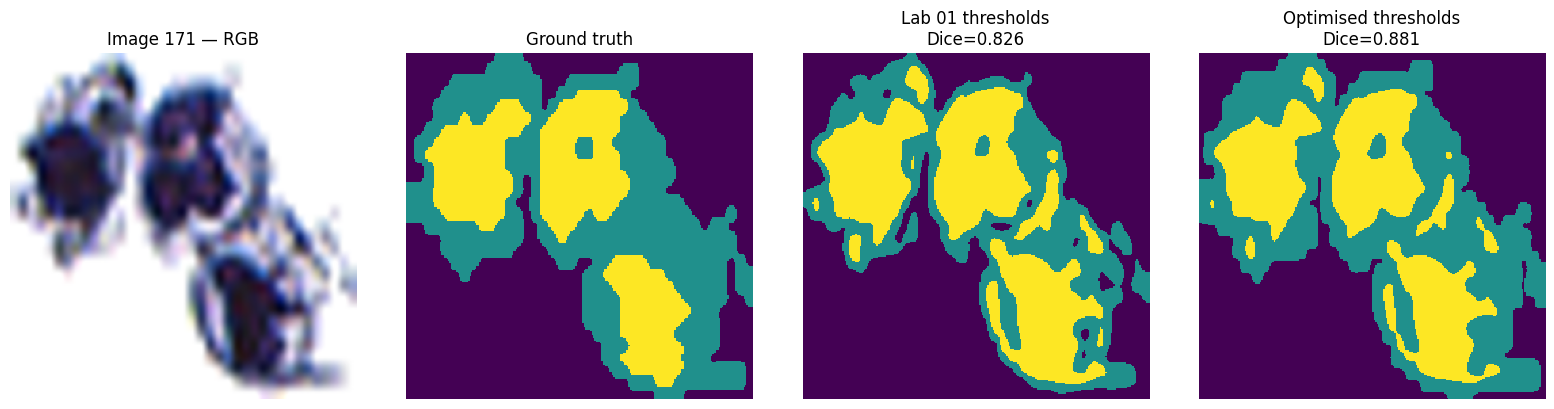

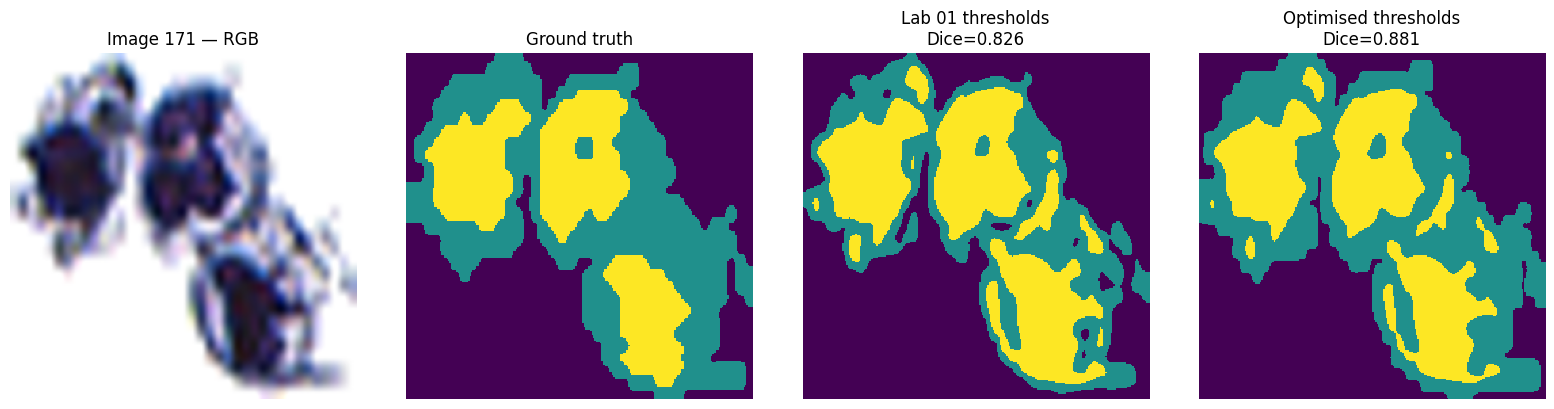

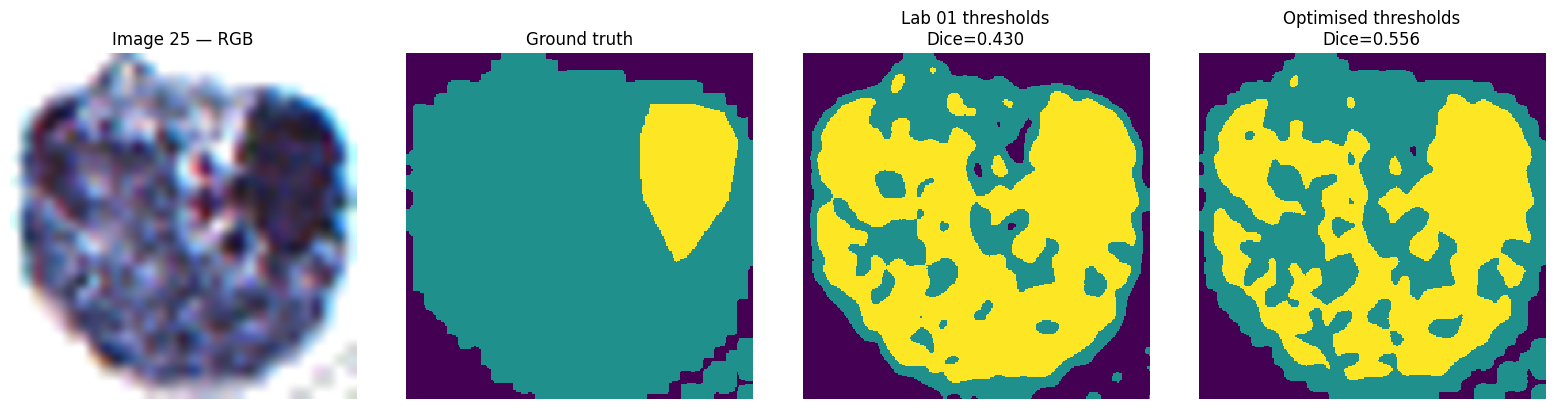

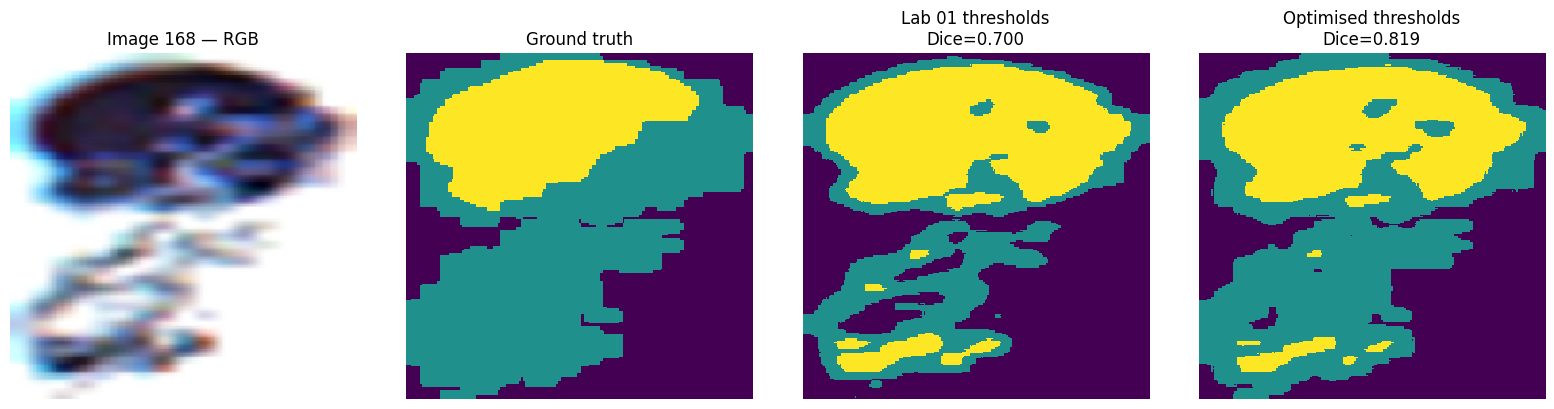

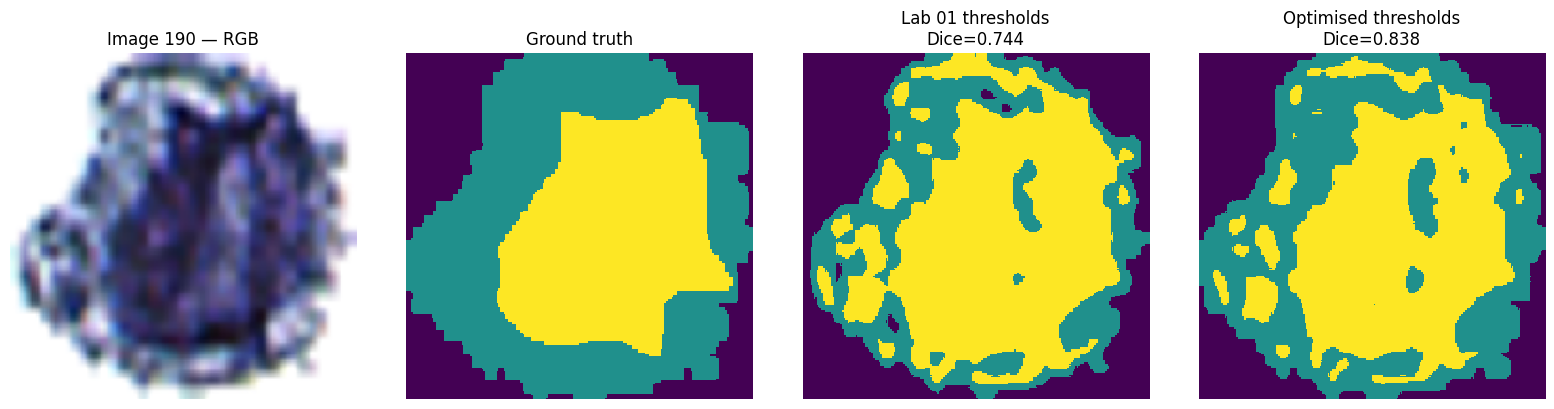

In [10]:
import random

for _ in range(5):
    sample = random.choice(test_idx)
    pred_lab01 = segment(X[sample], lab01_nuc, lab01_bg)
    pred_opt   = segment(X[sample], best_nuc,  best_bg)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(X[sample].transpose(1, 2, 0))
    axes[0].set_title(f'Image {sample} — RGB')
    axes[0].axis('off')

    axes[1].imshow(y[sample], cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[1].set_title('Ground truth')
    axes[1].axis('off')

    d01 = (dice_score(pred_lab01, y[sample], 1) + dice_score(pred_lab01, y[sample], 2)) / 2
    axes[2].imshow(pred_lab01, cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[2].set_title(f'Lab 01 thresholds\nDice={d01:.3f}')
    axes[2].axis('off')

    d_opt = (dice_score(pred_opt, y[sample], 1) + dice_score(pred_opt, y[sample], 2)) / 2
    axes[3].imshow(pred_opt, cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[3].set_title(f'Optimised thresholds\nDice={d_opt:.3f}')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

## Wrap-up

**Key takeaways:**
- Bayesian optimisation finds better thresholds than hand-picking, with only 50 evaluations.
- The convergence curve flattens quickly — most of the gain comes in the first 15–20 trials.
- Even the optimal thresholds are limited by the grayscale representation: if two classes
  overlap in intensity (which they do, as we saw in Lab 01's histogram), no threshold can
  perfectly separate them.  The representation is the bottleneck.

---

## Group Exercise — Evaluation Budget

How quickly does Bayesian optimisation converge?  Divide your group into three sub-groups
and run the optimiser with different evaluation budgets.

**Person A** — 10 evaluations (`n_calls=10`)  
**Person B** — 25 evaluations (`n_calls=25`)  
**Person C** — 50 evaluations (`n_calls=50`, already done above)  

For each budget, record:
1. The best threshold pair found.
2. The training-set Dice.
3. The **test-set** Dice.

Share your results, then discuss:
- Does doubling the budget always double the improvement?
- At what point does additional budget stop helping?
- What does this tell you about diminishing returns in hyperparameter search?

---

## Addendum — N/C Ratio: Effect of Optimised Thresholds (full dataset)

The two scatter plots below compare predicted vs true N/C ratio for all 191 images,
using the Lab 01 hand-picked thresholds (left) and the Bayesian-optimised thresholds (right).

The quality metric is **R² vs y = x** (see Lab 01 addendum).
Better thresholds reduce the deviation from the identity line and raise R².

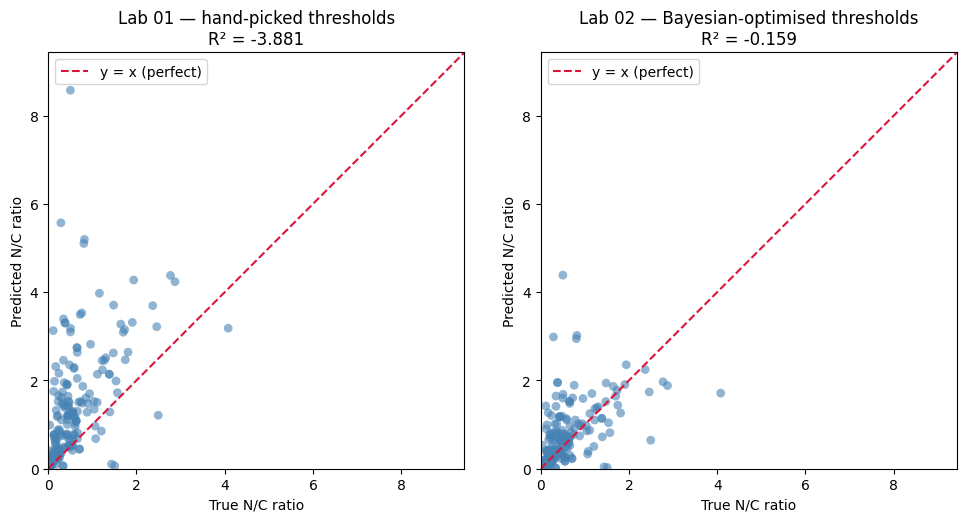

In [11]:
# ── N/C ratio for every image: hand-picked vs optimised thresholds ───────────────────
def nc_ratio(mask):
    """N/C ratio: nucleus pixels / cytoplasm pixels.  NaN if cytoplasm absent."""
    nuc = (mask == 2).sum()
    cyt = (mask == 1).sum()
    return nuc / cyt if cyt > 0 else np.nan

nc_true       = np.array([nc_ratio(y[i])                              for i in range(N)])
nc_pred_lab01 = np.array([nc_ratio(segment(X[i], lab01_nuc, lab01_bg)) for i in range(N)])
nc_pred_opt   = np.array([nc_ratio(segment(X[i], best_nuc,  best_bg))  for i in range(N)])

valid = np.isfinite(nc_true) & np.isfinite(nc_pred_lab01) & np.isfinite(nc_pred_opt)
xt, yp1, yp2 = nc_true[valid], nc_pred_lab01[valid], nc_pred_opt[valid]

def r2_identity(yp, xt):
    """R² vs y = x: 1 means perfect agreement with the identity line."""
    ss_res = np.sum((yp - xt) ** 2)
    ss_tot = np.sum((xt - xt.mean()) ** 2)
    return 1 - ss_res / ss_tot

r2_1 = r2_identity(yp1, xt)
r2_2 = r2_identity(yp2, xt)

lim = max(xt.max(), yp1.max(), yp2.max()) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

titles = [f'Lab 01 — hand-picked thresholds\nR² = {r2_1:.3f}',
          f'Lab 02 — Bayesian-optimised thresholds\nR² = {r2_2:.3f}']

for ax, yp, title in zip(axes, [yp1, yp2], titles):
    ax.scatter(xt, yp, alpha=0.6, color='steelblue', edgecolors='none', s=40)
    ax.plot([0, lim], [0, lim], color='crimson', linestyle='--',
            linewidth=1.5, label='y = x (perfect)')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('True N/C ratio')
    ax.set_ylabel('Predicted N/C ratio')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()